# Aadhaar Enrolment & Update Analysis
### Unlocking Societal Trends in Aadhaar Enrolment and Updates

#### This notebook contains the complete analysis conducted for the UIDAI Hackathon using aggregated Aadhaar enrolment, demographic update, and biometric update datasets provided by UIDAI.

#### > Note: The datasets are not included in this repository due to government data ownership and privacy guidelines.

#### (UIDAI Hackathon Submission)

## 1. Imports & Environment Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

plt.style.use("default")


## 2. Load & Combine FULL DATASETS (CRITICAL STEP)

### 2.1 Aadhaar Enrolment – ALL FILES

In [35]:
from glob import glob
import pandas as pd

# Match enrolment files by name pattern
enrolment_files = glob("api_data_aadhar_enrolment_*.csv")

print("Enrolment files found:", enrolment_files)

enrolment_df = pd.concat(
    [
        pd.read_csv(f, parse_dates=["date"], dayfirst=True)
        for f in enrolment_files
    ],
    ignore_index=True
)

print("Enrolment dataset shape:", enrolment_df.shape)
enrolment_df.head()


Enrolment files found: ['api_data_aadhar_enrolment_0_500000.csv', 'api_data_aadhar_enrolment_1000000_1006029.csv', 'api_data_aadhar_enrolment_500000_1000000.csv']
Enrolment dataset shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21


# Aadhaar Enrolment & Update Analysis
## Unlocking Societal Trends in Aadhaar Enrolment and Updates

### (UIDAI Hackathon Submission)

## 1. Imports & Environment Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

plt.style.use("default")


## 2. Load & Combine FULL DATASETS (CRITICAL STEP)

### 2.1 Aadhaar Enrolment – ALL FILES

In [35]:
from glob import glob
import pandas as pd

# Match enrolment files by name pattern
enrolment_files = glob("api_data_aadhar_enrolment_*.csv")

print("Enrolment files found:", enrolment_files)

enrolment_df = pd.concat(
    [
        pd.read_csv(f, parse_dates=["date"], dayfirst=True)
        for f in enrolment_files
    ],
    ignore_index=True
)

print("Enrolment dataset shape:", enrolment_df.shape)
enrolment_df.head()


Enrolment files found: ['api_data_aadhar_enrolment_0_500000.csv', 'api_data_aadhar_enrolment_1000000_1006029.csv', 'api_data_aadhar_enrolment_500000_1000000.csv']
Enrolment dataset shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21


### 2.2 Demographic Updates – ALL FILES

In [36]:
demo_files = glob("api_data_aadhar_demographic_*.csv")

print("Demographic files found:", demo_files)

demo_update = pd.concat(
    [
        pd.read_csv(f, parse_dates=["date"], dayfirst=True)
        for f in demo_files
    ],
    ignore_index=True
)

print("Demographic update dataset shape:", demo_update.shape)
demo_update.head()


Demographic files found: ['api_data_aadhar_demographic_0_500000.csv', 'api_data_aadhar_demographic_1000000_1500000.csv', 'api_data_aadhar_demographic_1500000_2000000.csv', 'api_data_aadhar_demographic_2000000_2071700.csv', 'api_data_aadhar_demographic_500000_1000000.csv']
Demographic update dataset shape: (2071700, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375
2,2025-03-01,Gujarat,Rajkot,360006,65,765
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314
4,2025-03-01,Rajasthan,Udaipur,313801,45,785


### 2.3 Biometric Update – ALL FILES

In [37]:
bio_files = glob("api_data_aadhar_biometric_*.csv")

print("Biometric files found:", bio_files)

bio_update = pd.concat(
    [
        pd.read_csv(f, parse_dates=["date"], dayfirst=True)
        for f in bio_files
    ],
    ignore_index=True
)

print("Biometric update dataset shape:", bio_update.shape)
bio_update.head()


Biometric files found: ['api_data_aadhar_biometric_0_500000.csv', 'api_data_aadhar_biometric_1000000_1500000.csv', 'api_data_aadhar_biometric_1500000_1861108.csv', 'api_data_aadhar_biometric_500000_1000000.csv']
Biometric update dataset shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,2025-03-01,Haryana,Mahendragarh,123029,280,577
1,2025-03-01,Bihar,Madhepura,852121,144,369
2,2025-03-01,Jammu and Kashmir,Punch,185101,643,1091
3,2025-03-01,Bihar,Bhojpur,802158,256,980
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815


In [38]:
print(enrolment_df.columns)
print(demo_update.columns)
print(bio_update.columns)

print(enrolment_df["date"].min(), enrolment_df["date"].max())


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')
2025-03-02 00:00:00 2025-12-31 00:00:00


## 3. Data Cleaning & Preprocessing

### 3.1 Aadhaar Enrolment Data

In [40]:
df = enrolment_df.copy()

df = df.dropna(subset=["date", "state", "district", "pincode"])

df["total_enrolment"] = (
    df["age_0_5"] +
    df["age_5_17"] +
    df["age_18_greater"]
)

df["month"] = df["date"].dt.to_period("M")


### 3.2 Update Datasets (Correct Age Logic)

In [41]:
demo_update = demo_update.dropna(subset=["state"])
bio_update  = bio_update.dropna(subset=["state"])

demo_update["total_demo_update"] = (
    demo_update["demo_age_5_17"] +
    demo_update["demo_age_17_"]
)

bio_update["total_bio_update"] = (
    bio_update["bio_age_5_17"] +
    bio_update["bio_age_17_"]
)


## 4. Research Question 1 (RQ1)

### How has Aadhaar enrolment changed over time?

### 4.1 Monthly Enrolment Trend

In [42]:
monthly_enrolment = (
    df.groupby("month")["total_enrolment"]
    .sum()
    .reset_index()
)

monthly_enrolment["month"] = monthly_enrolment["month"].astype(str)


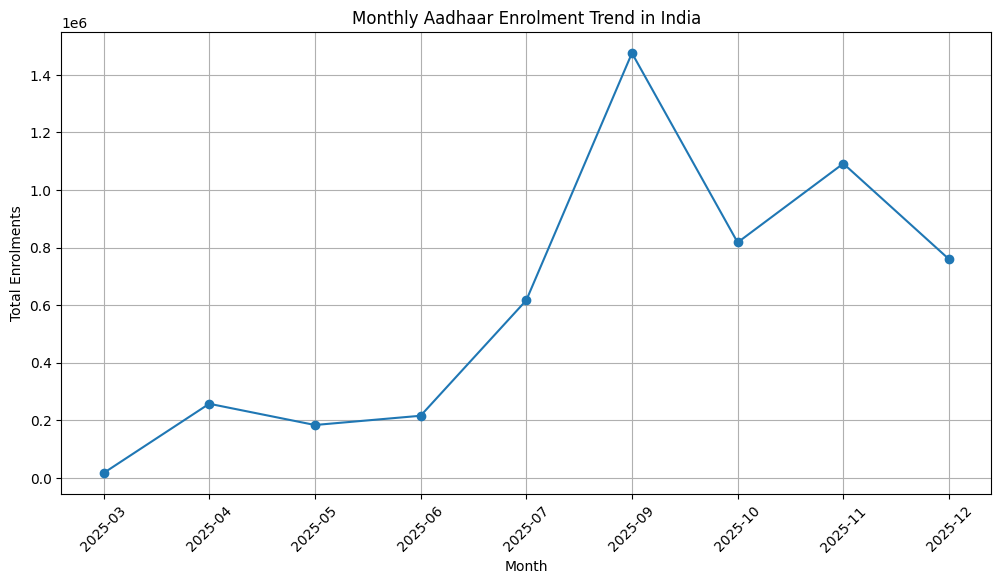

In [43]:
plt.figure(figsize=(12,6))
plt.plot(monthly_enrolment["month"], monthly_enrolment["total_enrolment"], marker="o")
plt.title("Monthly Aadhaar Enrolment Trend in India")
plt.xlabel("Month")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### 4.2 Age-wise Monthly Trends

In [44]:
monthly_age = (
    df.groupby("month")[["age_0_5", "age_5_17", "age_18_greater"]]
    .sum()
    .reset_index()
)

monthly_age["month"] = monthly_age["month"].astype(str)


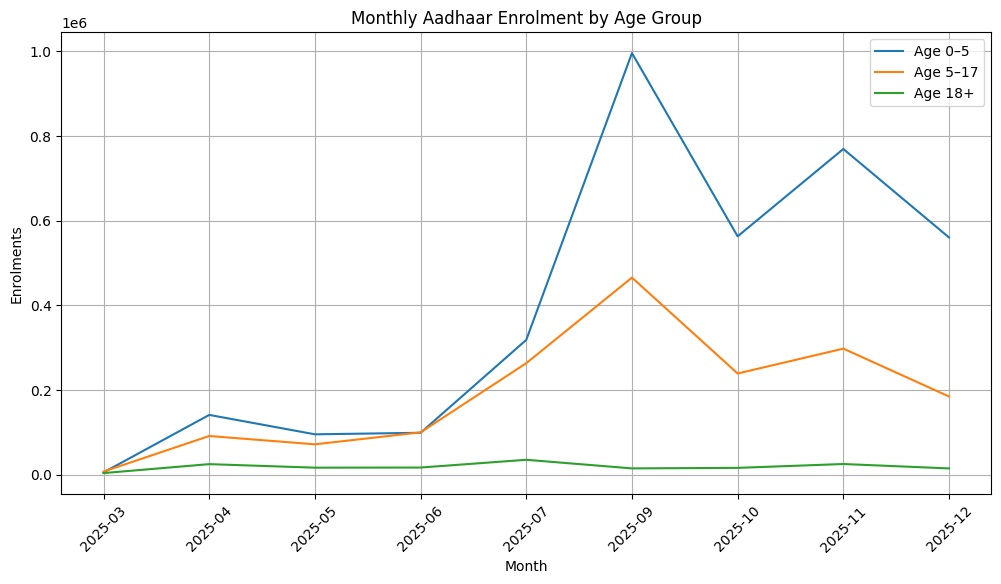

In [45]:
plt.figure(figsize=(12,6))
plt.plot(monthly_age["month"], monthly_age["age_0_5"], label="Age 0–5")
plt.plot(monthly_age["month"], monthly_age["age_5_17"], label="Age 5–17")
plt.plot(monthly_age["month"], monthly_age["age_18_greater"], label="Age 18+")
plt.title("Monthly Aadhaar Enrolment by Age Group")
plt.xlabel("Month")
plt.ylabel("Enrolments")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


## 5. Research Question 2 (RQ2)

### Are Aadhaar enrolments evenly distributed across states and districts?

### 5.1 State-wise Enrolment

In [46]:
state_enrolment = (
    df.groupby("state")["total_enrolment"]
    .sum()
    .reset_index()
    .sort_values(by="total_enrolment", ascending=False)
)


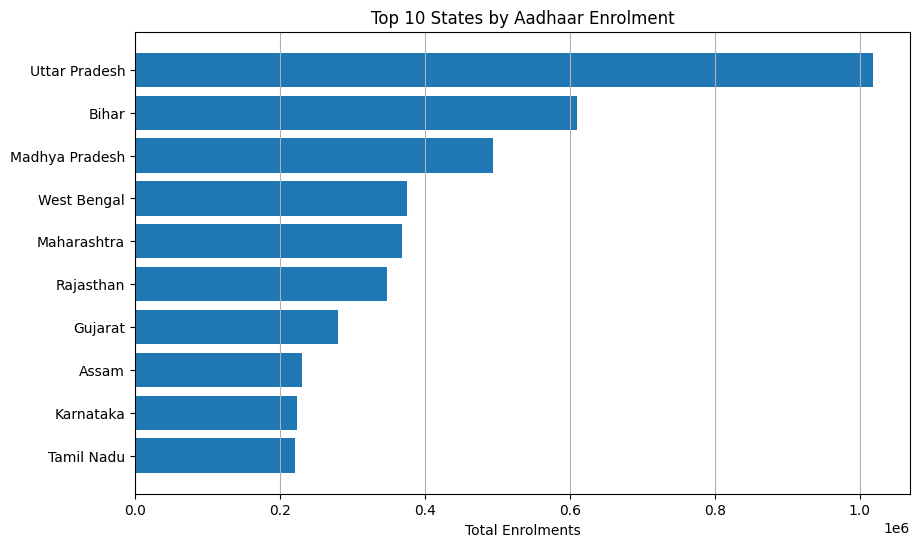

In [47]:
plt.figure(figsize=(10,6))
plt.barh(state_enrolment.head(10)["state"],
         state_enrolment.head(10)["total_enrolment"])
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xlabel("Total Enrolments")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


### 5.2 District-wise Enrolment (Lowest Performing)

In [48]:
district_enrolment = (
    df.groupby(["state", "district"])["total_enrolment"]
    .sum()
    .reset_index()
    .sort_values(by="total_enrolment")
)


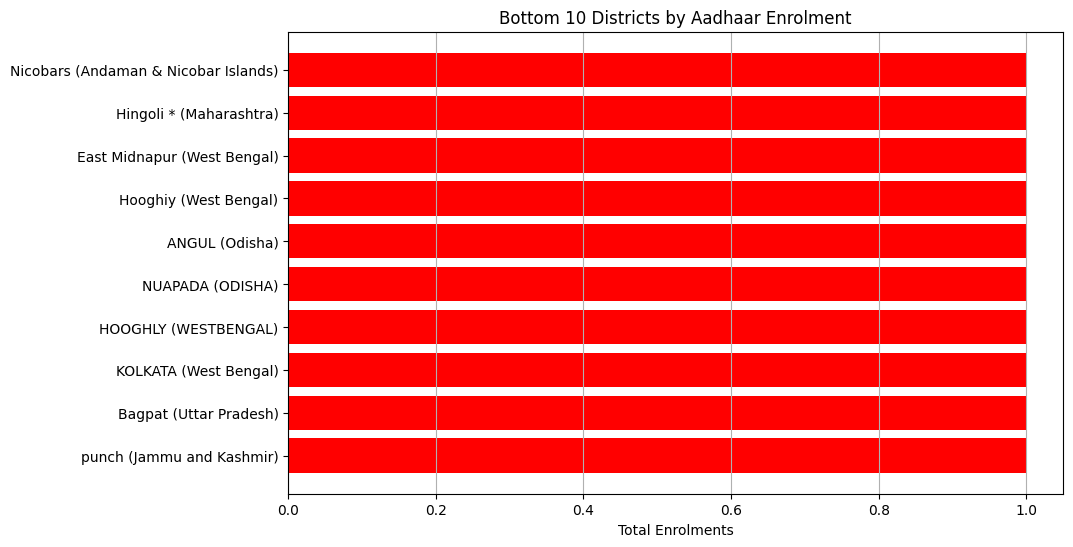

In [49]:
plt.figure(figsize=(10,6))
plt.barh(
    district_enrolment.head(10)["district"] + 
    " (" + district_enrolment.head(10)["state"] + ")",
    district_enrolment.head(10)["total_enrolment"],
    color="red"
)
plt.title("Bottom 10 Districts by Aadhaar Enrolment")
plt.xlabel("Total Enrolments")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


### 6. RQ2 (Extended)

### Age-wise Inequality Across States

In [50]:
state_age = (
    df.groupby("state")[["age_0_5", "age_5_17", "age_18_greater"]]
    .sum()
    .reset_index()
)

state_age["total"] = (
    state_age["age_0_5"] +
    state_age["age_5_17"] +
    state_age["age_18_greater"]
)

state_age["pct_0_5"] = state_age["age_0_5"] / state_age["total"] * 100
state_age["pct_5_17"] = state_age["age_5_17"] / state_age["total"] * 100
state_age["pct_18+"] = state_age["age_18_greater"] / state_age["total"] * 100


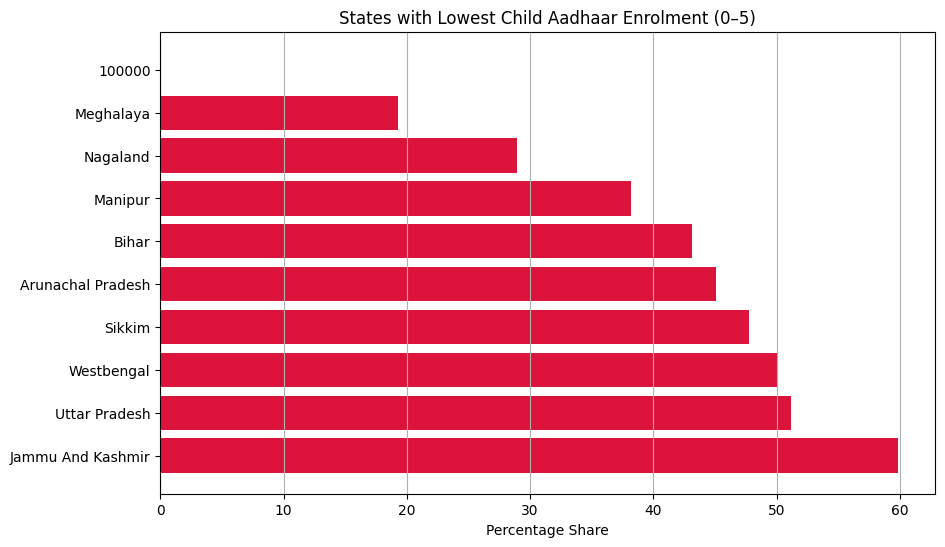

In [51]:
low_child = state_age.sort_values("pct_0_5").head(10)

plt.figure(figsize=(10,6))
plt.barh(low_child["state"], low_child["pct_0_5"], color="crimson")
plt.title("States with Lowest Child Aadhaar Enrolment (0–5)")
plt.xlabel("Percentage Share")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


## 7. Research Question 4 & 5 (RQ4–RQ5)

### Aadhaar Lifecycle Analysis (Updates vs Enrolment)

### 7.1 State-wise Update Aggregation

In [52]:
state_demo = (
    demo_update.groupby("state")["total_demo_update"]
    .sum()
    .reset_index()
)

state_bio = (
    bio_update.groupby("state")["total_bio_update"]
    .sum()
    .reset_index()
)


### 7.2 Merge Lifecycle Data

In [53]:
state_lifecycle = (
    state_age[["state", "total"]]
    .merge(state_demo, on="state", how="left")
    .merge(state_bio, on="state", how="left")
)

state_lifecycle[["total_demo_update", "total_bio_update"]] = (
    state_lifecycle[["total_demo_update", "total_bio_update"]].fillna(0)
)

state_lifecycle["demo_update_ratio"] = (
    state_lifecycle["total_demo_update"] / state_lifecycle["total"]
)

state_lifecycle["bio_update_ratio"] = (
    state_lifecycle["total_bio_update"] / state_lifecycle["total"]
)


### 7.3 Update Intensity Visualizations

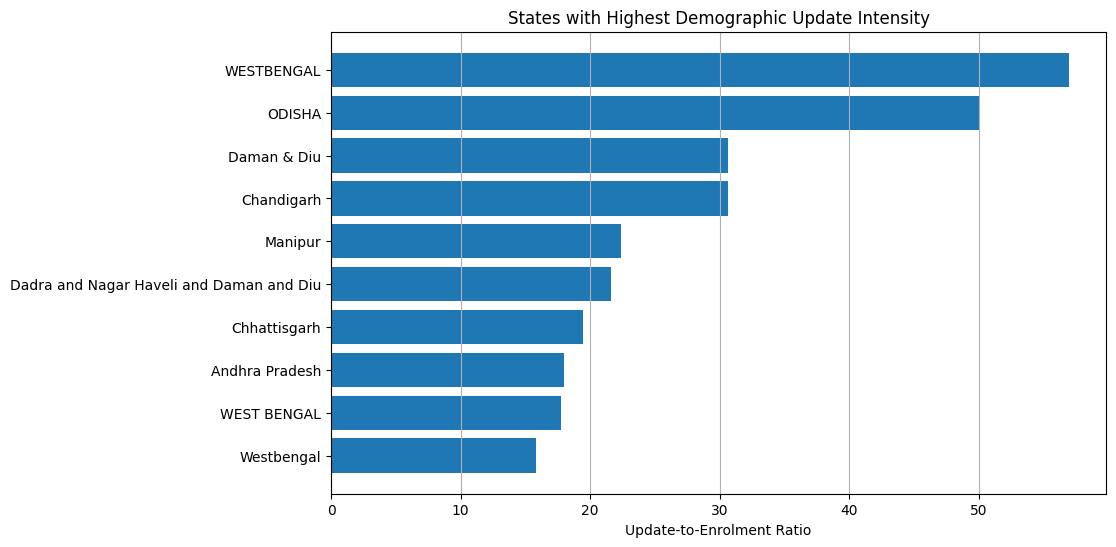

In [54]:
top_demo = state_lifecycle.sort_values(
    "demo_update_ratio", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_demo["state"], top_demo["demo_update_ratio"])
plt.title("States with Highest Demographic Update Intensity")
plt.xlabel("Update-to-Enrolment Ratio")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()


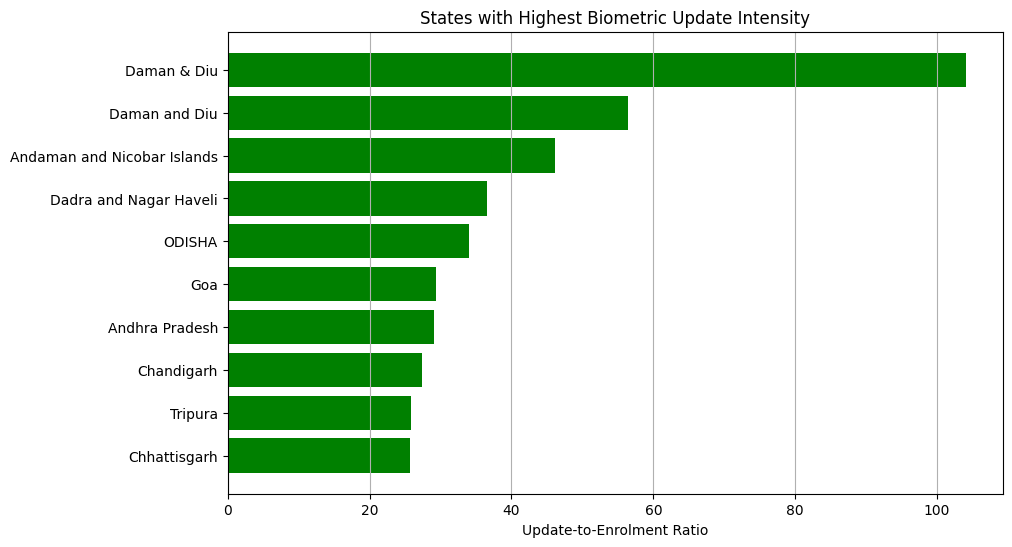

In [55]:
top_bio = state_lifecycle.sort_values(
    "bio_update_ratio", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_bio["state"], top_bio["bio_update_ratio"], color="green")
plt.title("States with Highest Biometric Update Intensity")
plt.xlabel("Update-to-Enrolment Ratio")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()
